# Titanic Dataset Analysis

From Kaggle: The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

# Tasks:



1.   Every step must have an explanation
2.   Every plot/ chart must have an iterpretation
3.   Add your observations for each section
4.   Draw clear conclusions (at least 5 conclusions)



In [278]:
import pandas as pd
## import pandas as the required library. pandas is a python data analysis library

In [279]:
##data = pd.re
## this step returns an error. the data object is not used anywhere below so it's safe to comment this out

In [280]:
train = pd.read_csv('https://raw.githubusercontent.com/niteen11/data301_predictive_analytics_machine_learning/main/data/titanic_train.csv')
## import the dataset in csv format and assign it to the "train" object

In [281]:
train.head()
## show the first five rows of the imported dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA (Exploratory Data Analysis)

In [282]:
import seaborn as sns
## import seaborn, a python data vis library

In [283]:
%matplotlib inline
## https://pypi.org/project/matplotlib-inline/: This package provides support for matplotlib to display figures directly inline in the Jupyter notebook and related clients. Apparently not required in newer versions of Jupyter notebooks.
import matplotlib.pyplot as plt
## import matplotlib, a data vis library specifically for plotting (figures / graphs)

<Axes: >

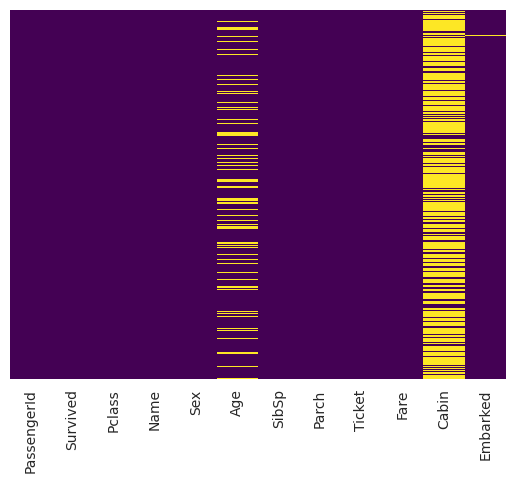

In [284]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
## create a heatmap visualization of the dataset based on the following parameters:
## train.isnull() returns a copy of the initial dataset with any missing values substituted with "True" and existing values substituted with "False"
## yticklabels=False: no labels on the y-axis
## cbar=False: no colorbar, i.e. no legend showing which colors match up to which values. This makes sense since there are only two values in the dataset, yellow=True=missing and purple=False=not missing
## cmap='viridis': use the viridis colormap, which runs from deep purple to yellow

## Class


<Axes: xlabel='Survived', ylabel='count'>

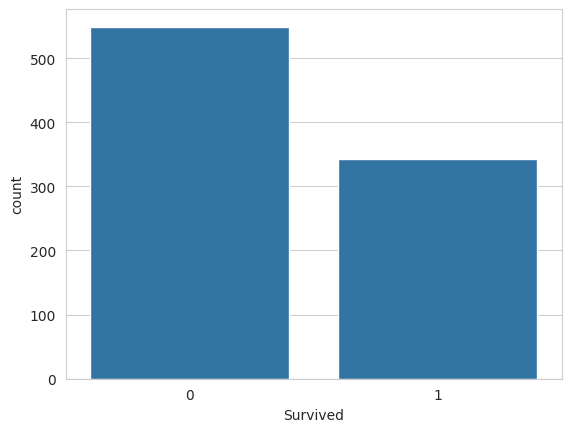

In [285]:
sns.set_style('whitegrid')
## set the "style" of the next seaborn plot. whitegrid is one of the available styles (white background, darker grid)
sns.countplot(x='Survived', data=train)
## a countplot is a plot of data divided into "bins" of values.
## plot the entire original dataset as a breakdown between two bins of the values in the Survived, feature (1 or 0). Label the x axis as "Survived"

## Survived

<Axes: xlabel='Survived', ylabel='count'>

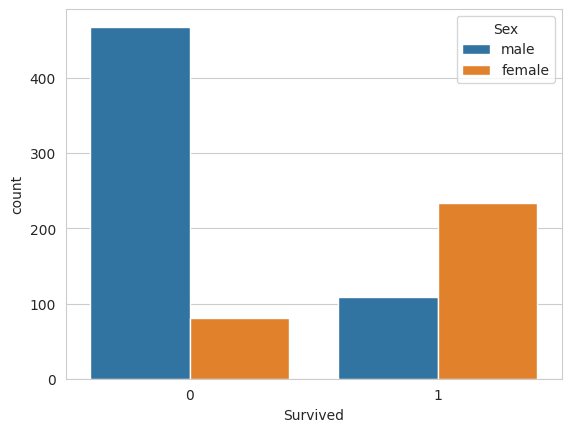

In [286]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train)
## plot the entire dataset as a breakdown between the bins of the values in the Sex column (values "male"/"female") divided according to the values in the Survived column (1 or 0).
## Label the x axis as "Survived".
## the hue parameter is added to create a second category breakdown (Sex in addition to Survived).

<Axes: xlabel='Survived', ylabel='count'>

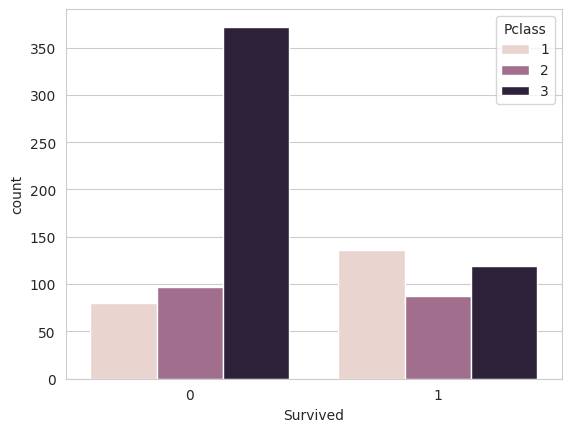

In [287]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train)
## plot the entire dataset as a breakdown between the bins of the values in the Pclass column (values 1, 2, 3) divided according to the values in the Survived column (1 or 0).
## Label the x axis as "Survived".
## the hue parameter is added to create a second category breakdown (Pclass in addition to Survived).

## Age

/tmp/ipykernel_824/3638243408.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde=False, bins=30)


<Axes: xlabel='Age'>

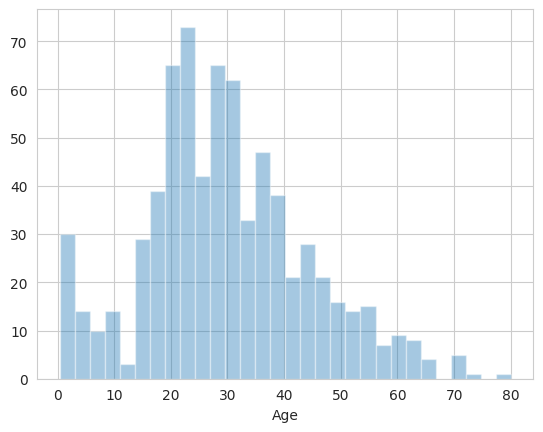

In [288]:
sns.distplot(train['Age'].dropna(), kde=False, bins=30)
## train['Age'].dropna() removes any rows with no values in the Age column and returns a copy of the dataframe with only the Age column retained.
## kde=False: the displayed figure is a histogram rather than a more smoothed-out "Kernel density estimation" curve
## bins=30: the histogram is divided into 30 bins or buckets

## Siblings

<Axes: xlabel='SibSp', ylabel='count'>

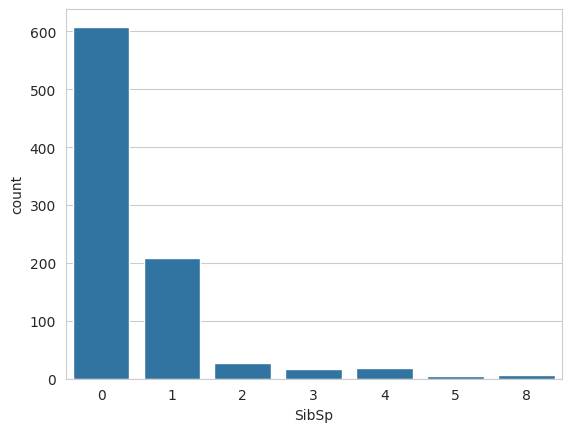

In [289]:
sns.countplot(x='SibSp',data=train)
## creates a countplot (see above) of the SibSp (number of siblings or spouses per passenger) column.
## The graph indicates that most passengers (~600) traveled alone while ~200 passengers traveled with one sibling or spouse.

# Data Cleaning and Data Pre - Processing

In [290]:
train.drop('Cabin', axis=1, inplace= True)
## modify the original "train" dataset (inplace=True) to drop feature "Cabin"

In [291]:
train.dropna(inplace=True)
## modify the original "train" dataset (inplace=True) to remove all rows with at least one missing value

In [292]:
sex = pd.get_dummies(train['Sex'], drop_first=True)
## one-hot encode the values in column Sex (1/0 for each sex instead of male/female) and assign the resulting dataframe to var "sex"

embark = pd.get_dummies(train['Embarked'], drop_first=True)
## one-hot encode the values in column Embarked (1/0 for each port instead of S, C, etc.) and assign the resulting dataframe to var "embark"

In [293]:
train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace= True)
## drop columns 'Sex','Embarked','Name','Ticket'. The first two have been hot-encoded.
## 'Name' and 'Ticket' (i.e. ticket id number) are irrelevant to training the prediction model.

In [294]:
train.head()
## show the first five rows of the newly processed dataset.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [295]:
train = pd.concat([train, sex, embark],axis=1)
## concat the one-hot dataframes "sex" and "embark" to the processed dataset

In [296]:
train.head()
## show the first five rows of the resulting dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


# Model building

In [297]:
from sklearn.model_selection import train_test_split
## import the train_test_split function from the scikit_learn library

In [298]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1), train['Survived'],test_size=0.3, random_state=101)
## splits the "train" dataset into a training dataset and a test dataset
## Function parameters:
## train.drop('Survived',axis=1): the feature dataset, which is the original dataset with the Survived column removed
## train['Survived']: the target dataset, which is the Survived column from the original dataset
## test_size=0.3: the train/test split is 70% training set to 30% testing set.
## random_state=101: random_state constant ensures that the split is the same (i.e. the same rows are in the train and test datasets) every time the code is run
## Function returns:
## X_train: the feature training dataset (70% of the original dataset with the Survived column removed)
## X_test: the feature testing dataset (30% of the original dataset with the Survived column removed)
## y_train: the target training dataset (70% of the original dataset's Survived column)
## y_test: the target testing dataset (30% of the original dataset's Survived column)

In [299]:
from sklearn.linear_model import LogisticRegression
## import the logistic regression model

In [300]:
logmodel = LogisticRegression(max_iter=1000)
## initialize the logistic regression model object
## added parameter max_iter=1000: the default maximum number of training iterations for LogisticRegression is 100.
## This was too low and resulted in error STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

In [301]:
logmodel.fit(X_train, y_train)
## train the model on the training dataset

LogisticRegression(max_iter=1000)

In [302]:
predict = logmodel.predict(X_test)
## run the predictions against the test feature set with the trained model
## Predicted values: Survived = 0 or 1

## Classification report

In [303]:
from sklearn.metrics import classification_report

In [304]:
print(classification_report(y_test,predict))
## use the scikit-learn classification_report function to display classification metrics for our logistic regression model
## columns:
## precision: measures how many of the predicted target values (Survived = 0 or 1) were correct
## recall: measures how many of the predicted target values (Survived = 0 or 1) the model was able to find
## f1-score: measures prediction accuracy by calculating the "harmonic mean" of precision and recall values. The harmonic mean is better that the standard mean for datasets with unbalanced values (e.g. here far fewer people survived than died)
## support: how many values of each class (Survived = 0 or 1) are in the test dataset. Shows the imbalance between the two values in our dataset.
## rows:
## accuracy: the number of correct predictions divided by the total number of rows in the test dataset.
## macro avg: the simple arithmetic mean of the column value for each class: (precision(survived=0) + precision(survived = 1) / 2). Shows the overall accuracy across the dataset, ignores the value imbalance.
## weighted avg: the weighted mean that takes into account the number of values for each class: (precision(survived=0) * support(survived=0) + precision(survived=1)* support(survived=1)) / total support number i.e. number of rows.
##
## The fact that precision, recall and f1-score values are the same for each type of average means that the model is balanced when predicting the values for each class.
## The fact that precision, recall and f1-score values are close across macro and weighted averages (0.79 vs 0.80) indicates that the model is equally good at predicting both classes (Survived = 0 or 1) in spite of the value imbalance.

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       128
           1       0.77      0.72      0.74        86

    accuracy                           0.80       214
   macro avg       0.79      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214



## Confusion Matrix

In [305]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, predict))
## import the confusion_matrix function, generate and print the confusion matrix:
## True Positives (TP)  False Positives (FP)
## False Negatives (FN)  True Negatives (TN)

[[109  19]
 [ 24  62]]


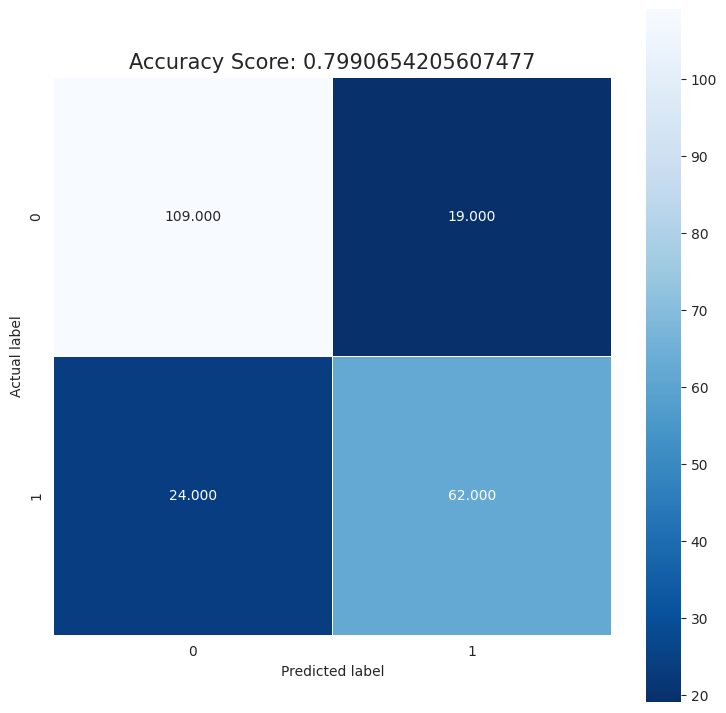

In [306]:
## print out the confusion using the seaborn heatmap function, color-coded with shades of blue.
## The figure title is the accuracy score, which is the same as two cells above but printed with higher precision.

plt.figure(figsize=(9,9))
sns.heatmap(confusion_matrix(y_test, predict), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(logmodel.score(X_test, y_test))
plt.title(all_sample_title, size = 15);

In [307]:
##from sklearn import  metrics

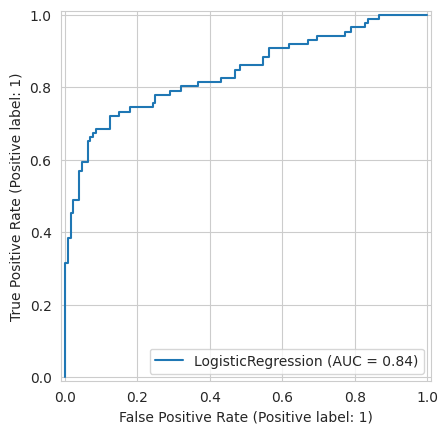

In [308]:
##metrics.plot_roc_curve(logmodel, X_test, y_test)
## The function plot_roc_curve was deprecated in scikit-learn version 1.0
## replaced with RocCurveDisplay.from_estimator(logmodel, X_test, y_test) below

from sklearn.metrics import RocCurveDisplay

## Display the Receiver Operating Characteristic (ROC) curve for the trained model and the test dataset
RocCurveDisplay.from_estimator(logmodel, X_test, y_test)

## Observation: the area under the curve (AUC) for the ROC curve above is 0.84. The better the model's accuracy, the closer the AUC will be to 1.

# Conclusion...

In [309]:
## Conclusion: the logistic regression model was trained against a dataset with the following features:
## Pclass (cabin class 1, 2, 3)
## Age
## SibSp (number of siblings or spouses traveling with passenger)
## Parch (number of parents or children traveling with passenger)
## Fare
## Hot-encoded values for sex (male-female)
## Hot-encoded values for points of embarkation
## The trained model was able to predict survival rate with decent accuracy (0.8). The macro and weighted averages for the precision, recall and f1-score values indicated that the model was reasonably good at predicting both survival rate and death rate, in spite of the imbalance of these values in the original dataset.
## The confusion matrix showed 109 true positives and 62 true negatives out of 214 total rows in the test dataset.

In [310]:
## Possible improvements to the model

## combine the columns indicating the number of fellow travelers into a single column and drop 'SibSp' and 'Parch'
train['Fellow Travelers'] = train['SibSp'] + train['Parch']
train.drop(['SibSp','Parch'], axis=1, inplace= True)


## drop the fare column as it is likely redundant with Pclass
train.drop('Fare', axis=1, inplace=True)

## drop the one-hot-encoded embarkation columns
train.drop(['Q','S'], axis=1, inplace=True)


In [311]:
## split the newly formed dataset into train and test sets, as above
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1), train['Survived'],test_size=0.3, random_state=42)

## train the model on the modified dataset
logmodel.fit(X_train, y_train)

## run the predictions using the retrained model
predict = logmodel.predict(X_test)


In [312]:
print(classification_report(y_test,predict))


              precision    recall  f1-score   support

           0       0.78      0.88      0.83       122
           1       0.81      0.67      0.73        92

    accuracy                           0.79       214
   macro avg       0.79      0.78      0.78       214
weighted avg       0.79      0.79      0.79       214



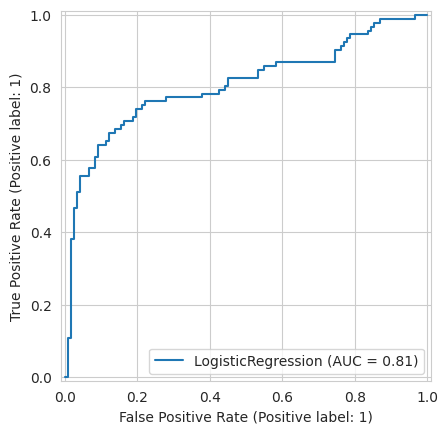

In [313]:
RocCurveDisplay.from_estimator(logmodel, X_test, y_test)

## The accuracy went down slightly (0.8 -> 0.79).
## The AUC for the ROC curve is also lower (0.84 -> 0.81).
## Thus, the modifications resulted in a lower-quality prediction model.